### Programming Assignment 1 (Basic Text Preprocessing and Tokenization)
Phone Myat Ko Ko - 662115512

#### Requirements
To run this notebook , you will need to install:nltk,textblob,spacy using "pip install <package_name>"

#### Importing Necessary Package

In [53]:
import re
import timeit

import nltk
import pandas as pd
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\iileg\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\iileg\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\iileg\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#### Clean Text
The clean_text() function loads the alice29.txt text file from the resource/cantrbry/ directory and performs a series of preprocessing operations to produce a normalized, lower-cased text string.
- The function opens the file resource/cantrbry/alice29.txt in read mode using UTF-8 encoding.
- Reads the entire file content into memory as a single string.
- Converts all newline characters (\n) into spaces.
- Replaces all occurrences of the character 'r' with a space.
- Uses a regular expression to remove all characters that are not alphanumeric (\w) or whitespace (\s).This effectively strips punctuation such as commas, periods, apostrophes, quotes, and symbols.
- Collapses multiple consecutive whitespace characters into a single space.
- Removes leading and trailing whitespace.
- Converts the entire text to lowercase before returning it.


In [54]:
def clean_text():
    with open('resource/cantrbry/alice29.txt','r',encoding='utf-8') as file:
        text=file.read()
        text=text.replace('\n',' ').replace('\r',' ')
        text=re.sub(r'[^\w\s]','',text)
        text=re.sub(r'\s+',' ',text).strip()
    return text.lower()

### Using nltk framework

In [57]:
def nltk_ver():
  texts=clean_text()
  stopwords=nltk.corpus.stopwords.words('english')
  tokens=nltk.word_tokenize(texts)
  
  #Remove stopwords
  tokens=[token for token in tokens if token not in stopwords]
  texts= ' '.join([word for word in tokens])
  
  with open('output/nltk/cleaned.txt', 'w',encoding='utf-8') as outfile:
        outfile.write(texts)
  
  with open('output/nltk/words.txt', 'w',encoding='utf-8') as tokenfile:
    for token in tokens:
        tokenfile.write(token + '\n')      
  freq_dists=nltk.FreqDist(tokens)
  #Choose top 10 words
  top10s=freq_dists.most_common(10)
  with open('output/nltk/top10.txt', 'w',encoding='utf-8') as top10file:
    for word, counts in top10s:
        top10file.write(f'{word}: {counts}\n')      





### Using textBlob

In [58]:
from textblob import TextBlob
def textblob_ver():
    text=clean_text()
    stopwords=nltk.corpus.stopwords.words("english")
    blob=TextBlob(text)
    tokens=blob.words

    #Remove stopwords
    tokens=[token for token in tokens if token not in stopwords]
    cleaned_text=' '.join(tokens)
    with open('output/textblob/cleaned.txt','w',encoding='utf-8') as outfile:
        outfile.write(cleaned_text)
    
    with open('output/textblob/words.txt','w',encoding='utf-8') as outfile:
        for token in tokens:
            outfile.write(token+'\n')
    
    freq_dist=nltk.FreqDist(tokens)
    #Choose top 10 words
    top10=freq_dist.most_common(10)
    with open('output/textblob/top10.txt','w',encoding='utf-8') as outfile:
        for word,count in top10:
            outfile.write(f"{word}:{count}\n")


    

#### Using spaCy

In [59]:
import spacy
def spacy_ver():
    text=clean_text()
    nlp=spacy.load("en_core_web_sm")
    stopwords=nlp.Defaults.stop_words
    spacy_doc=nlp(text)
    tokens=[token.text for token in spacy_doc ]
    
    #Remove stopwords
    tokens=[token for token in tokens if token not in stopwords]
    cleaned_text=' '.join(tokens)
    with open('output/spacy/cleaned.txt','w',encoding='utf-8') as outfile:
        outfile.write(cleaned_text)
    
    with open('output/spacy/words.txt','w',encoding='utf-8') as outfile:
        for token in tokens:
            outfile.write(token+'\n')
            
    freq_dist=nltk.FreqDist(tokens)
    #Choose top 10 words
    top10=freq_dist.most_common(10)
    with open('output/spacy/top10.txt','w',encoding='utf-8') as outfile:
        for word,count in top10:
            outfile.write(f"{word}:{count}\n")
    


#### Time Comparison
Each framework function is run 10 times and then divided by 10 for average duration

In [60]:
nltk_time=timeit.timeit(nltk_ver,number=10)/10
textblob_time=timeit.timeit(textblob_ver,number=10)/10
spacy_time=timeit.timeit(spacy_ver,number=10)/10
time_compare_df=pd.DataFrame({
    'Framework':['NLTK','TextBlob','SpaCy'],
    'Time(Seconds)':[nltk_time,textblob_time,spacy_time]
})
print(time_compare_df)
with open('output/timecompared.txt','w',encoding='utf-8') as outfile:
    outfile.write(time_compare_df.to_string(index=False))
    

  Framework  Time(Seconds)
0      NLTK       0.149455
1  TextBlob       0.191729
2     SpaCy       7.673064


#### Visualization of time comparison among frameworks

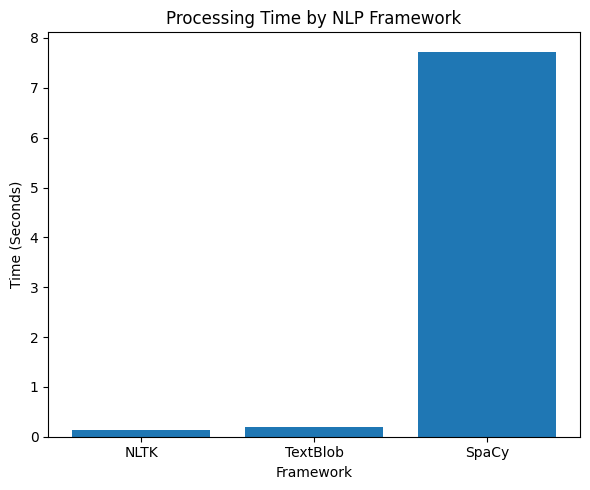

In [52]:
plt.figure(figsize=(6, 5))
plt.bar(time_compare_df["Framework"],time_compare_df["Time(Seconds)"])
plt.xlabel("Framework")
plt.ylabel("Time (Seconds)")
plt.title("Processing Time by NLP Framework")
plt.tight_layout()
plt.show()